In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)

In [2]:
# 컬렴명 확인
df.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')

In [3]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 컬럼을 숫자로 변환
df.loc[:, 'buying'] = label_encoder.fit_transform(df['buying'])
df.loc[:, 'maint'] = label_encoder.fit_transform(df['maint'])
df.loc[:, 'doors'] = label_encoder.fit_transform(df['doors'])
df.loc[:, 'persons'] = label_encoder.fit_transform(df['persons'])
df.loc[:, 'lug_boot'] = label_encoder.fit_transform(df['lug_boot'])
df.loc[:, 'safety'] = label_encoder.fit_transform(df['safety'])
df.loc[:, 'class'] = label_encoder.fit_transform(df['class'])

In [4]:
df['buying'] = df['buying'].astype('float64')
df['maint'] = df['maint'].astype('float64')
df['doors'] = df['doors'].astype('float64')
df['persons'] = df['persons'].astype('float64')
df['lug_boot'] = df['lug_boot'].astype('float64')
df['safety'] = df['safety'].astype('float64')
df['class'] = df['class'].astype('float64')

In [5]:
X=df.drop('class',axis=1)
X.head()

,buying,maint,doors,persons,lug_boot,safety
0,3.0,3.0,0.0,0.0,2.0,1.0
1,3.0,3.0,0.0,0.0,2.0,2.0
2,3.0,3.0,0.0,0.0,2.0,0.0
3,3.0,3.0,0.0,0.0,1.0,1.0
4,3.0,3.0,0.0,0.0,1.0,2.0


In [6]:
y=df['class']
y.head()

0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
Name: class, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [8]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam

model = Sequential()

# Input 레이어 추가
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(10, activation='tanh'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(6, activation='tanh'))
model.add(Dense(1, activation='softmax'))

model.compile(Adam(learning_rate=0.04), 'categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219 (876.00 B)

 Trainable params: 219 (876.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델 학습
model_history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# 예측값 계산
y_pred = model.predict(X_test)

# 예측값과 실제 값을 클래스 번호로 변환
y_test_class = np.argmax(y_test, axis=0)
y_pred_class = np.argmax(y_pred, axis=0)

# 예측된 클래스와 실제 클래스 비교
print(y_test_class)
print(y_pred_class)

Epoch 1/30


c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\losses\losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


25/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0313 - loss: 0.0000e+00 

c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\losses\losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0331 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0361 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0374 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0396 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0406 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0331 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0403 - loss: 0.0000e+00 - val_accuracy: 0.0486 - val_loss: 0.0000e+00
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0365 - l

c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


c:\Users\tonyd\anaconda3\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


44
[0]


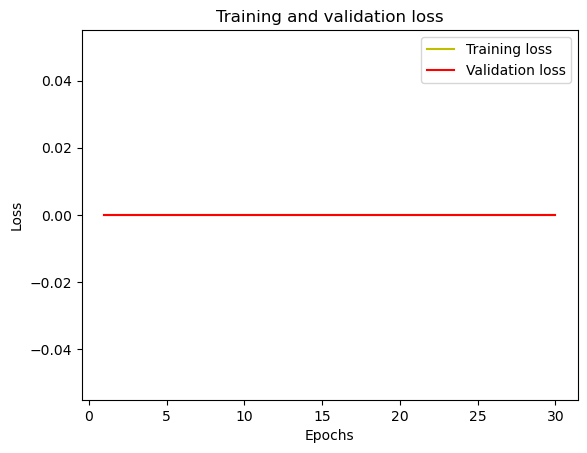

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

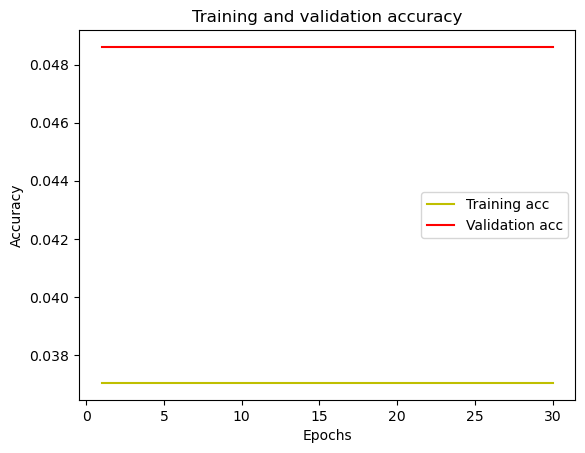

In [11]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        99
         1.0       0.05      1.00      0.09        21
         2.0       0.00      0.00      0.00       296
         3.0       0.00      0.00      0.00        16

    accuracy                           0.05       432
   macro avg       0.01      0.25      0.02       432
weighted avg       0.00      0.05      0.00       432

[[  0  99   0   0]
 [  0  21   0   0]
 [  0 296   0   0]
 [  0  16   0   0]]


c:\Users\tonyd\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tonyd\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tonyd\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
